# Linear Regression — Solution

**Dataset:** Rental apartments in Zurich: area, rooms and monthly rent.

Run from top to bottom. The steps match the exercise; short answers explain the results.

## Libraries and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 1. Calculate OLS with three apartments

The OLS formula is in the concept notebook. Replace the gap with `np.sum((x - x_mean) * (y - y_mean))`. The remaining calculation is provided. What are the slope and intercept? Is the 95 m² prediction interpolation or extrapolation for these three flats?

In [2]:
x = np.array([40, 60, 80])
y = np.array([1200, 1600, 2000])
x_mean = x.mean()
y_mean = y.mean()
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
slope = numerator / denominator
intercept = y_mean - slope * x_mean
print('Slope:', slope, 'Intercept:', intercept)
print('Predicted rent for 95 m²:', intercept + slope * 95)
# A separate R² illustration:
print('R² for SSE=20 and SST=100:', 1 - 20 / 100)

Slope: 20.0 Intercept: 400.0
Predicted rent for 95 m²: 2300.0
R² for SSE=20 and SST=100: 0.8


**Answer:** Slope = 20 CHF per m² and intercept = 400 CHF.

- The mean area is 60 m² and the mean rent is 1600 CHF.
- The numerator is (−20)(−400) + 0 · 0 + 20 · 400 = 16 000; the denominator is 400 + 0 + 400 = 800. The slope is 16 000 / 800 = 20.
- The intercept is 1600 − 20 · 60 = 400.
- The fitted line is: rent = 400 + 20 · area. One extra m² corresponds to 20 CHF more predicted rent.
- For 95 m²: 400 + 20 · 95 = 2300 CHF/month. 95 m² lies outside the observed 40–80 m², so this is extrapolation.
- In the separate R² example: 1 − 20 / 100 = 0.8, so 80% of the variation in the training target is explained.

## 2. Load apartments

Preparation is provided. What does a point in this plot represent? Describe the overall pattern.

        area  rooms   price
count  571.0  571.0   571.0
mean    86.9    3.4  2454.2
std     34.8    1.2   797.2
min     15.0    1.0  1005.0
25%     63.0    2.5  1831.5
50%     86.0    3.5  2345.0
75%    105.0    4.5  2950.0
max    270.0    7.5  4960.0


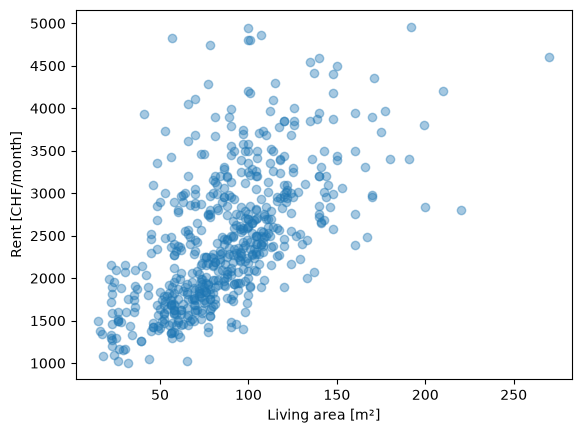

In [3]:
apt = pd.read_csv('../00_Data/rental_apartments_canton_zh.csv', sep=';')
apt = apt[['bfs_name', 'rooms', 'area', 'price']].dropna().drop_duplicates()
apt = apt[(apt['price'] >= 1000) & (apt['price'] <= 5000)]
train, test = train_test_split(apt, test_size=0.2, random_state=42)
print(train[['area', 'rooms', 'price']].describe().round(1))
plt.scatter(train['area'], train['price'], alpha=0.4)
plt.xlabel('Living area [m²]')
plt.ylabel('Rent [CHF/month]')
plt.show()

**Answer:** Each point is one apartment in the training set (571 flats).

- Areas range from 15 to 270 m² (median 86 m²); rents range from 1005 to 4960 CHF/month (mean 2454 CHF).
- Larger flats generally have higher rents: the cloud rises from left to right.
- The scatter is wide: flats of about 80–100 m² rent for anything from roughly 1500 to 4500 CHF. Area alone will therefore leave large errors.

## 3. Fit simple OLS

Replace the gap with `smf.ols("price ~ area", data=train).fit()`. Interpret the printed area coefficient.

Intercept    1248.20
area           13.87
dtype: float64
Training R²: 0.368


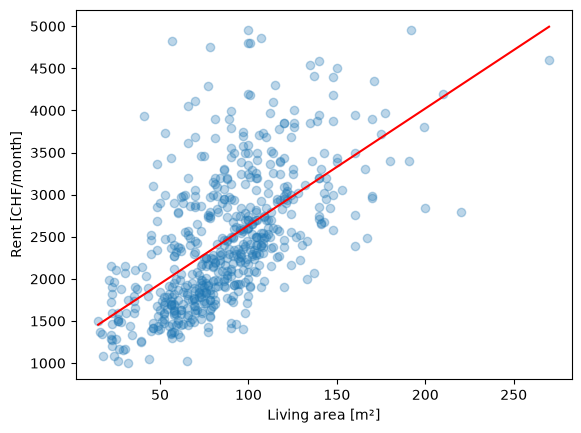

In [4]:
simple = smf.ols("price ~ area", data=train).fit()
print(simple.params.round(2))
print('Training R²:', round(simple.rsquared, 3))
grid = pd.DataFrame({'area': np.linspace(train['area'].min(), train['area'].max(), 100)})
plt.scatter(train['area'], train['price'], alpha=0.3)
plt.plot(grid['area'], simple.predict(grid), color='red')
plt.xlabel('Living area [m²]')
plt.ylabel('Rent [CHF/month]')
plt.show()

**Answer:** The fitted line is: rent = 1248.20 + 13.87 · area.

- Each extra m² corresponds to 13.87 CHF/month more predicted rent, on average.
- Example: a 100 m² flat gets 1248.20 + 1387 = 2635 CHF/month; a 50 m² flat gets 1248.20 + 693.50 = 1942 CHF/month.
- The intercept of 1248.20 CHF is the prediction at 0 m². It only places the line; it is not a realistic rent.
- Training R² = 0.368: area explains about 37% of the variation in rents. The other 63% comes from location, condition, and other factors not in the model.

## 4. Read intervals for 95 m²

Which columns describe average rent? Which interval concerns one new apartment?

In [5]:
new_flat = pd.DataFrame({'area': [95]})
intervals = simple.get_prediction(new_flat).summary_frame(alpha=0.05)
print(intervals[['mean', 'mean_ci_lower', 'mean_ci_upper',
                 'obs_ci_lower', 'obs_ci_upper']].round(0))

     mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  2566.0         2513.0         2620.0        1319.0        3814.0


**Answer:** `mean_ci_lower` and `mean_ci_upper` describe the average rent; `obs_ci_lower` and `obs_ci_upper` concern one new apartment.

- Predicted rent for 95 m²: 1248.20 + 13.87 · 95 ≈ 2566 CHF/month.
- 95% confidence interval for the **average** rent of all 95 m² flats: 2513 to 2620 CHF (about ± 53 CHF). It is narrow because 571 flats determine the line well.
- 95% prediction interval for **one** new 95 m² flat: 1319 to 3814 CHF (about ± 1248 CHF). It is about 23 times wider, because single flats scatter widely around the average.

## 5. Add rooms

Replace the gap with `smf.ols("price ~ area + rooms", data=train).fit()`. What does the area coefficient now mean?

In [6]:
multiple = smf.ols("price ~ area + rooms", data=train).fit()
print(multiple.params.round(2))
print('Training R²:', round(multiple.rsquared, 3))
print('Input correlations:')
print(train[['area', 'rooms']].corr().round(2))

Intercept    1294.87
area           15.48
rooms         -54.42
dtype: float64
Training R²: 0.369
Input correlations:
       area  rooms
area   1.00   0.86
rooms  0.86   1.00


**Answer:** The area coefficient is now 15.48 CHF per m², for flats with the same number of rooms.

- The fitted model is: rent = 1294.87 + 15.48 · area − 54.42 · rooms.
- Example: two flats with 3.5 rooms, one 10 m² larger, differ by 154.80 CHF in predicted rent.
- The rooms coefficient is −54.42: for a fixed area, one extra room goes with 54 CHF lower rent. More rooms in the same area means smaller rooms.
- Area and rooms are strongly correlated (0.86), so the data contain few flats that differ in one input but not the other. Their separate effects are hard to estimate, which is why the area coefficient changed from 13.87 to 15.48.
- Training R² rises only from 0.368 to 0.369: rooms adds almost no information beyond area.

## 6. Check residuals

Do you see a curve or a funnel in the residual plot? Can the Q–Q plot establish independence?

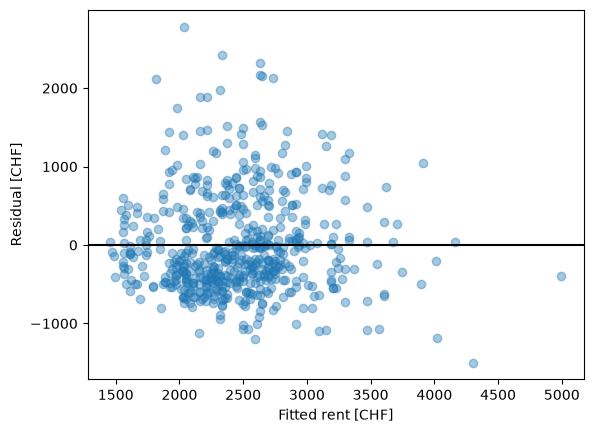

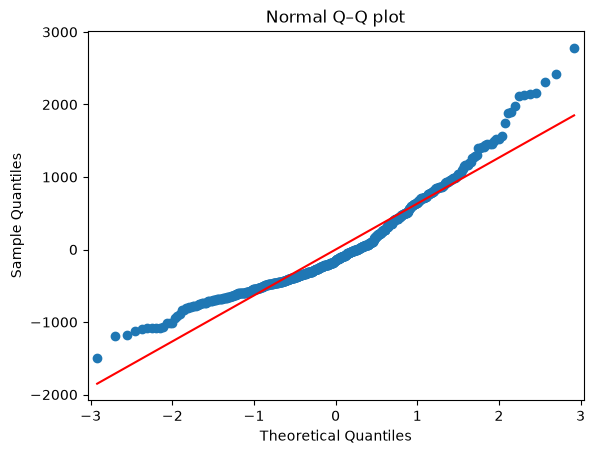

In [7]:
plt.scatter(simple.fittedvalues, simple.resid, alpha=0.4)
plt.axhline(0, color='black')
plt.xlabel('Fitted rent [CHF]')
plt.ylabel('Residual [CHF]')
plt.show()
sm.qqplot(simple.resid, line='s')
plt.title('Normal Q–Q plot')
plt.show()

**Answer:**

- **Curve:** the residuals scatter around 0 without a clear bend, so a straight line describes the average trend reasonably well.
- **Funnel:** the vertical spread is roughly similar across fitted rents (about −1500 to +2800 CHF), so there is no strong funnel.
- **Skew:** the residuals are not symmetric. Positive residuals reach about +2800 CHF, while negative ones stop near −1500 CHF. Some flats are much more expensive than their area suggests, but few are much cheaper. The 1000–5000 CHF rent filter also cuts off the extremes.
- **Q–Q plot:** both ends of the curve lie above the red line, which confirms this right-skewed shape: the errors are not normally distributed.
- **Independence:** the Q–Q plot cannot establish independence. Independence must be assessed from the study design, e.g. flats in the same municipality or building may be similar.

## 7. Final test evaluation

These two models are fixed before this test comparison. Which has lower RMSE? What does RMSE of 500 CHF mean? Use CV for further model choices, rather than repeated test comparisons.

In [8]:
simple_pred = simple.predict(test)
multiple_pred = multiple.predict(test)
print('Simple test RMSE:', round(np.sqrt(mean_squared_error(test['price'], simple_pred)), 1))
print('Multiple test RMSE:', round(np.sqrt(mean_squared_error(test['price'], multiple_pred)), 1))
print('Simple test R²:', round(r2_score(test['price'], simple_pred), 3))
print('Multiple test R²:', round(r2_score(test['price'], multiple_pred), 3))

Simple test RMSE: 705.5
Multiple test RMSE: 710.3
Simple test R²: 0.312
Multiple test R²: 0.302


**Answer:** The simple model has the lower test RMSE: 705.5 CHF/month compared with 710.3 CHF/month for the multiple model.

- Test R² is 0.312 for the simple model and 0.302 for the multiple model.
- Both are a little lower than the training R² (0.368 and 0.369), as expected for new data.
- The extra rooms input did not improve test predictions here. This matches the almost unchanged training R² in step 5.
- An RMSE of 705.5 CHF means that a typical prediction error for a new flat is about 700 CHF/month. Predicting the average rent for every flat would give an error close to the rent's standard deviation of about 800 CHF.
- An RMSE of 500 CHF would mean a typical prediction error of 500 CHF/month. It is not an error bound for each flat: single flats can be off by much more.

### Jupyter notebook — footer info

Include this information when submitting your notebook.

In [9]:
import platform
from datetime import datetime
print(platform.platform())
print("Python:", platform.python_version())
print("Date:", datetime.now().isoformat(timespec="seconds"))

Linux-6.8.0-1064-azure-x86_64-with-glibc2.41
Python: 3.11.16
Date: 2026-10-02T19:32:46
